# Data Preparation

This notebook turns the workbook `myVal_Synthetic_Datasets_release_v2.xlsx` into the modelling tables (`train_df`, `val_df` and `test_df`) for the household contents-value regression.

**Idea:** A customer has documented only **N items** (N = 10, 20, 30 or 50), and the model predicts the **total value of all contents** of the home from those N items. Real logs of partial documentation do not exist, so they are **simulated**. Every home in the data has its full inventory, so a random subset of N items can be drawn while the true total remains known.

**Rules used throughout**
- **Vehicles are excluded:** A vehicle is not a contents-insurance item, and each vehicle is worth many times an ordinary item.
- **Items without a value are dropped:** Items with no `Current_Estimated_Value` are removed, so every item in the inventory has a value.
- **Minimum of 10 items per property:** Five items are too few to say anything about a home, and a home with exactly 5 items would be sampled in full.
- **Split by property:** The train, validation and test sets are split by `Property_ID`. They are rebuilt from the classification model's own data (`data/processed/model_state.csv`, the output of `02_fm_target_definition`) with the same code as its `03_fm_modelling`, so both models see the same households in the same partition.

**Steps in this notebook**
1. Convert the workbook sheets to parquet once and store them in `data/interim/regression/`.
2. Build the target `true_total_value` per property, excluding vehicles.
3. Simulate N-item samples (N = 10, 20, 30, 50) with 5 random draws for each N.
4. Turn each sample into one row of features.
5. Split by `Property_ID` with the classification model's grouped split and save the tables to `data/processed/regression/`.
6. Run the checks, show the distributions and the saved files, repeat the final check against the classification model, and summarise what the notebook produced.

**What the data looks like** (see `01_ky_eda_dataset`): The workbook has only 7 item categories (6 without vehicles), the item data is real AI output, and most homes have very few items. Large baskets can therefore only be built for a few homes.

In [1]:
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import time
import numpy as np, pandas as pd

# Folder layout (as in the repository):
#   ../../data/raw                  = the workbook
#   ../../data/interim/regression   = parquet copy of the sheets and the property split
#   ../../data/processed            = model_state.csv (classification) and, in regression/, the modelling tables
RAW = Path("../../data/raw")
INTERIM = Path("../../data/interim/regression")
INTERIM.mkdir(parents=True, exist_ok=True)
PROCESSED = Path("../../data/processed/regression")
PROCESSED.mkdir(parents=True, exist_ok=True)
XLSX = RAW / "myVal_Synthetic_Datasets_release_v2.xlsx"
MODEL_STATE = Path("../../data/processed/model_state.csv")       # output of 02_fm_target_definition (classification model)
RANDOM_STATE = 42
print("interim folder:  ", INTERIM)
print("processed folder:", PROCESSED)

interim folder:   ..\..\data\interim\regression
processed folder: ..\..\data\processed\regression


## Block 1 — one-time: convert the slow `.xlsx` sheets to parquet

In [2]:
SHEETS = ["assets", "properties", "customers", "customer_profiles"]
t0 = time.time()
for s in SHEETS:
    f = INTERIM / f"{s}.parquet"
    if f.exists():
        print(f"{s}.parquet already exists - skipped")
        continue
    pd.read_excel(XLSX, sheet_name=s).to_parquet(f, index=False)
    print(f"wrote {f.name}")
print(f"done in {time.time() - t0:.1f}s")

assets.parquet already exists - skipped
properties.parquet already exists - skipped
customers.parquet already exists - skipped
customer_profiles.parquet already exists - skipped
done in 0.0s


## Block 2 — fast reload from parquet

In [3]:
assets = pd.read_parquet(INTERIM / "assets.parquet")
properties = pd.read_parquet(INTERIM / "properties.parquet")
customers = pd.read_parquet(INTERIM / "customers.parquet")
customer_profiles = pd.read_parquet(INTERIM / "customer_profiles.parquet")
for n, d in [("assets", assets), ("properties", properties), ("customers", customers), ("customer_profiles", customer_profiles)]:
    print(f"{n:18s}", d.shape)

assets             (8309, 26)
properties         (795, 19)
customers          (500, 15)
customer_profiles  (500, 15)


## Block 3 — ground truth (the target) and household features

- **Vehicles are excluded:** A vehicle is not a contents-insurance item, and each vehicle is worth many times an ordinary item, so it would dominate the target.
- **Items without a value are left out:** Items with no `Current_Estimated_Value` are removed, so every item in the inventory has a value.
- **Target:** `true_total_value` is the sum of `Current_Estimated_Value` over all remaining items of the property.
- **Household features:** These exist independently of what has been documented and consist of the property type, occupancy, number of occupants, number of bedrooms and property valuation.

In [4]:
CONTENTS_CATEGORIES = sorted(assets.loc[assets["Category"] != "Vehicles", "Category"].unique())
assets_contents = assets[assets["Category"] != "Vehicles"].copy()
print(f"{len(CONTENTS_CATEGORIES)} contents categories (Vehicles excluded):", CONTENTS_CATEGORIES)
print(f"items: {len(assets):,} total -> {len(assets_contents):,} after removing {len(assets) - len(assets_contents)} vehicle items")

# Some items have NO estimated value (the AI could not value them). A missing value would silently
# count as 0 in the target and make sums NaN in the features, so those items are left out of the inventory.
n_null = assets_contents["Current_Estimated_Value"].isna().sum()
assets_contents = assets_contents[assets_contents["Current_Estimated_Value"].notna()].copy()
print(f"items with no Current_Estimated_Value dropped: {n_null} -> {len(assets_contents):,} valued contents items remain")

true_value = (assets_contents.groupby("Property_ID")["Current_Estimated_Value"].sum()
              .rename("true_total_value").reset_index())

customers_features = customers[["Customer_ID", "Age_Band", "Membership_Level"]].copy()
profile_features = customer_profiles[["Customer_ID", "Income_Band", "Household_Type"]].copy()
prop_features = properties[["Property_ID", "Customer_ID", "Property_Type", "Occupancy_Type",
                            "Number_Of_Occupants", "Number_Of_Bedrooms", "Property_Valuation_AUD"]].copy()
prop_features = (prop_features.merge(customers_features, on="Customer_ID", how="left")
                 .merge(profile_features, on="Customer_ID", how="left")
                 .fillna({"Age_Band": "Unknown", "Membership_Level": "Unknown", "Income_Band": "Unknown", "Household_Type": "Unknown"}))

household = prop_features.merge(true_value, on="Property_ID", how="inner")
print("properties with a usable target:", household.shape[0], "/", properties.shape[0])
household.head()

6 contents categories (Vehicles excluded): ['Appliances', 'Clothings', 'Electronics', 'Furniture', 'Jewellery and Personal Items', 'Other Items']
items: 8,309 total -> 8,287 after removing 22 vehicle items
items with no Current_Estimated_Value dropped: 215 -> 8,072 valued contents items remain
properties with a usable target: 790 / 795


,Property_ID,Customer_ID,Property_Type,Occupancy_Type,Number_Of_Occupants,Number_Of_Bedrooms,Property_Valuation_AUD,Age_Band,Membership_Level,Income_Band,Household_Type,true_total_value
0,PRP-000001,CUS-00001,house,owner,2,3,96526,25-34,free,50k_75k,single,599.0
1,PRP-000002,CUS-00002,house,tenant,1,1,46711,25-34,free,under_50k,single_parent,75.0
2,PRP-000003,CUS-00003,terrace,owner,2,3,87279,25-34,free,100k_150k,couple_no_children,59150.0
3,PRP-000004,CUS-00004,villa,owner,3,4,111576,25-34,free,over_150k,family_with_children,2748.0
4,PRP-000005,CUS-00005,house,owner,4,4,128225,35-44,free,over_150k,share_house,2249.0


## Block 4 — simulate "the customer has documented N items"

For each property, N of its own items are drawn **at random without replacement**, and this is repeated 5 times for each N.
- **Minimum size:** A property with fewer than **10** items is skipped entirely.
- **Availability:** A property cannot produce a sample of size N if it owns fewer than N items.
- **No mixing:** Each property is sampled only from **its own** items. Properties are never combined, even when they belong to the same customer.

In [5]:
SAMPLE_SIZES = [10, 20, 30, 50]
REPEATS_PER_N = 5
MIN_ITEMS_REQUIRED = 10

rng = np.random.default_rng(RANDOM_STATE)
assets_by_property = {pid: grp.reset_index(drop=True) for pid, grp in assets_contents.groupby("Property_ID")}

def generate_samples(property_id, items_df, sample_sizes, repeats):
    n_available = len(items_df)
    if n_available < MIN_ITEMS_REQUIRED:
        return
    for n in sample_sizes:
        if n > n_available:
            continue
        for _ in range(repeats):
            idx = rng.choice(n_available, size=n, replace=False)
            yield n, items_df.iloc[idx]

items_per_prop = pd.Series({p: len(g) for p, g in assets_by_property.items()}).reindex(properties.Property_ID).fillna(0).astype(int)
feas = pd.DataFrame({"properties that can give this N": {N: int((items_per_prop >= N).sum()) for N in SAMPLE_SIZES}})
feas["share of all properties (%)"] = (100 * feas.iloc[:, 0] / len(properties)).round(1)
feas.index.name = "N"
print(f"properties skipped (< {MIN_ITEMS_REQUIRED} items): {(items_per_prop < MIN_ITEMS_REQUIRED).sum()} of {len(properties)}")
feas

properties skipped (< 10 items): 636 of 795

,properties that can give this N,share of all properties (%)
N,,
10,159,20.0
20,101,12.7
30,68,8.6
50,40,5.0


## Block 5 — turn one sample into one row of features

In [6]:
def featurize_sample(sample_items: pd.DataFrame, prop_row: pd.Series) -> dict:
    values = sample_items["Current_Estimated_Value"].to_numpy(dtype=float)
    feats = {
        "item_count": len(values),
        "sum_value": values.sum(),
        "mean_value": values.mean(),
        "median_value": np.median(values),
        "max_value": values.max(),
        "min_value": values.min(),
        "std_value": values.std() if len(values) > 1 else 0.0,
        "n_categories_seen": sample_items["Category"].nunique(),
    }
    # value documented so far in each category (0 if that category was not drawn)
    cat_sums = sample_items.groupby("Category")["Current_Estimated_Value"].sum()
    for cat in CONTENTS_CATEGORIES:
        col = "cat_" + cat.lower().replace(" ", "_").replace("(", "").replace(")", "").replace("/", "_")
        feats[col] = float(cat_sums.get(cat, 0.0))
    # household context (same for every sample of this property)
    feats["property_type"] = prop_row["Property_Type"]
    feats["occupancy_type"] = prop_row["Occupancy_Type"]
    feats["number_of_occupants"] = prop_row["Number_Of_Occupants"]
    feats["number_of_bedrooms"] = prop_row["Number_Of_Bedrooms"]
    feats["property_valuation_aud"] = prop_row["Property_Valuation_AUD"]
    return feats

# worked example on one property that has at least 20 items (so N = 10 and N = 20 both exist)
example_pid = items_per_prop[items_per_prop >= 20].index[0]
ex_items = assets_by_property[example_pid]
ex_row = household.loc[household["Property_ID"] == example_pid].iloc[0]
print(f"{example_pid}: {len(ex_items)} items, true total = ${ex_row['true_total_value']:,.0f}")
for n, sample in generate_samples(example_pid, ex_items, [10, 20], 2):
    print(f"  N={n:>2}: documented value = ${sample['Current_Estimated_Value'].sum():>9,.0f} "
          f"({sample['Current_Estimated_Value'].sum() / ex_row['true_total_value']:.0%} of the true total)")
featurize_sample(sample, ex_row)

PRP-000011: 36 items, true total = $41,532
  N=10: documented value = $   11,434 (28% of the true total)
  N=10: documented value = $   10,590 (25% of the true total)
  N=20: documented value = $   19,308 (46% of the true total)
  N=20: documented value = $   19,624 (47% of the true total)


{'item_count': 20,
 'sum_value': np.float64(19624.0),
 'mean_value': np.float64(981.2),
 'median_value': np.float64(375.0),
 'max_value': np.float64(5000.0),
 'min_value': np.float64(120.0),
 'std_value': np.float64(1315.6391830589419),
 'n_categories_seen': 4,
 'cat_appliances': 320.0,
 'cat_clothings': 0.0,
 'cat_electronics': 16204.0,
 'cat_furniture': 1600.0,
 'cat_jewellery_and_personal_items': 0.0,
 'cat_other_items': 1500.0,
 'property_type': 'house',
 'occupancy_type': 'owner',
 'number_of_occupants': np.int64(2),
 'number_of_bedrooms': np.int64(4),
 'property_valuation_aud': np.int64(114808)}

## Block 6 — assemble the modelling table and split by property (train / validation / test = the classification model's split)

**Split rule:** The split is made by `Property_ID` and never by row, and it is **the same grouped split as the classification model** (234 properties: 163 train, 35 validation and 36 test). One property gives up to 20 near-identical rows with the same true total and overlapping items, so keeping all rows of a property on one side prevents leakage.

**How it is built:** The split is rebuilt in the next cell from `data/processed/model_state.csv` (431 states from 234 properties, the output of `02_fm_target_definition`) with the two `GroupShuffleSplit` steps of `03_fm_modelling`. The first step keeps 70% for train, the second cuts the remaining 30% into validation and test in equal parts, and both use `random_state=42` and always group by `Property_ID`. The "Final check" at the end of this notebook confirms that the rebuild reproduces the counts printed there (train 309 rows from 163 properties, validation 67 from 35, test 55 from 36).

K-fold (`GroupKFold`, 5 folds) is used inside the classification model's training set only, to tune hyperparameters. It never defines the validation or test set.

Each regression property receives the label the classification model gave it, with no re-drawing:

| Property is in… | regression set |
|---|---|
| the classification train set | **train** |
| the classification validation set | **validation** |
| the classification test set | **test** |
| none of the classification sets (a home with 10+ items that never forms a classification state) | **unlisted**: It has no label to follow, so it is kept out of train, validation and test and saved separately (`unlisted_df.parquet`). Setting `INCLUDE_UNLISTED_IN_TRAIN = True` in the cell below adds these homes to train instead, which does not leak because they can never be in the classification test set. |

The full mapping is saved to `data/interim/regression/property_split.csv`.

In [7]:
rows = []
household_indexed = household.set_index("Property_ID")
for pid, items_df in assets_by_property.items():
    if pid not in household_indexed.index:
        continue
    prop_row = household_indexed.loc[pid]
    for n, sample_df in generate_samples(pid, items_df, SAMPLE_SIZES, REPEATS_PER_N):
        feats = featurize_sample(sample_df, prop_row)
        feats["Property_ID"] = pid
        feats["n_documented"] = n
        feats["true_total_value"] = prop_row["true_total_value"]
        rows.append(feats)

dataset = pd.DataFrame(rows)
dataset = pd.get_dummies(dataset, columns=["property_type", "occupancy_type"], drop_first=False)
print("dataset shape:", dataset.shape)

# --- split: the classification model's train / validation / test split, rebuilt from its own data (by Property_ID) ---
# Same two GroupShuffleSplit steps as in 03_fm_modelling (70% train, then 50 / 50 validation / test, random_state = 42),
# run on data/processed/model_state.csv (the output of 02_fm_target_definition).
from sklearn.model_selection import GroupShuffleSplit

INCLUDE_UNLISTED_IN_TRAIN = False                           # False = keep the homes the classification model never saw out of train

model_state = pd.read_csv(MODEL_STATE, usecols=["Property_ID", "Next_Category"])
state_pid = model_state["Property_ID"]
state_y = model_state["Next_Category"]

train_idx, temp_idx = next(GroupShuffleSplit(n_splits=1, train_size=0.70, random_state=42).split(model_state, state_y, groups=state_pid))
val_pos, test_pos = next(GroupShuffleSplit(n_splits=1, train_size=0.50, random_state=42).split(
    model_state.iloc[temp_idx], state_y.iloc[temp_idx], groups=state_pid.iloc[temp_idx]))
state_split = pd.Series("", index=model_state.index)
state_split.iloc[train_idx] = "train"
state_split.iloc[temp_idx[val_pos]] = "validation"
state_split.iloc[temp_idx[test_pos]] = "test"
prop_cls = state_split.groupby(state_pid).first()           # one label per property (a property is never split)

cls = prop_cls.rename("classifier_split").reset_index()
prop_split = (dataset[["Property_ID"]].drop_duplicates().merge(cls, on="Property_ID", how="left")
              .fillna({"classifier_split": "not_in_classifier"}))
prop_split["regression_split"] = prop_split["classifier_split"].replace(
    {"not_in_classifier": "train" if INCLUDE_UNLISTED_IN_TRAIN else "unlisted"})

label = dataset["Property_ID"].map(prop_split.set_index("Property_ID")["regression_split"])
train_df = dataset[label == "train"].reset_index(drop=True)
val_df = dataset[label == "validation"].reset_index(drop=True)
test_df = dataset[label == "test"].reset_index(drop=True)
unlisted_df = dataset[label == "unlisted"].reset_index(drop=True)

FEATURE_COLS = [c for c in dataset.columns if c not in ("Property_ID", "true_total_value")]
print(len(FEATURE_COLS), "feature columns")

prop_split = (prop_split.merge(properties[["Property_ID", "Customer_ID"]], on="Property_ID", how="left")
              .sort_values(["regression_split", "classifier_split", "Property_ID"]).reset_index(drop=True))
prop_split.to_csv(INTERIM / "property_split.csv", index=False)
train_df.to_parquet(PROCESSED / "train_df.parquet", index=False)
val_df.to_parquet(PROCESSED / "val_df.parquet", index=False)
test_df.to_parquet(PROCESSED / "test_df.parquet", index=False)
if len(unlisted_df):
    unlisted_df.to_parquet(PROCESSED / "unlisted_df.parquet", index=False)
print(f"train {len(train_df):,} rows | validation {len(val_df):,} | test {len(test_df):,} | unlisted (not used) {len(unlisted_df):,}")
print("saved train_df / val_df / test_df (and unlisted_df) to", PROCESSED, "and property_split.csv to", INTERIM)

dataset shape: (1840, 28)


26 feature columns


train 1,030 rows | validation 230 | test 150 | unlisted (not used) 430
saved train_df / val_df / test_df (and unlisted_df) to ..\..\data\processed\regression and property_split.csv to ..\..\data\interim\regression


## Checks on the split

In [8]:
parts = {"train": train_df, "validation": val_df, "test": test_df}
ids = {k: set(d["Property_ID"]) for k, d in parts.items()}
for k, d in parts.items():
    print(f"{k:<11}: {len(d):>6,} rows | {len(ids[k])} properties")
print(f"unlisted   : {len(unlisted_df):>6,} rows | {unlisted_df['Property_ID'].nunique()} properties (no classification label, not used)")
overlap = len(ids["train"] & ids["validation"]) + len(ids["train"] & ids["test"]) + len(ids["validation"] & ids["test"])
print("properties in more than one of train / validation / test:", overlap, " <- must be 0")

cnt = pd.concat({k: pd.DataFrame({"rows": d["n_documented"].value_counts(), "properties": d.groupby("n_documented")["Property_ID"].nunique()})
                 for k, d in parts.items()}, axis=1).sort_index().fillna(0).astype(int)
cnt.index.name = "N documented"
display(cnt)

# customers whose properties fall on different sides (split is by property, not by customer)
cust = properties.set_index("Property_ID")["Customer_ID"]
side = pd.concat([pd.Series(k, index=list(v)) for k, v in ids.items()])
side = pd.DataFrame({"side": side, "customer": cust.reindex(side.index)})
print("customers with properties in more than one of train / validation / test:", int((side.groupby("customer")["side"].nunique() > 1).sum()))
print("\nfeature groups:")
print("  summary  :", [c for c in FEATURE_COLS if c in ("item_count","sum_value","mean_value","median_value","max_value","min_value","std_value","n_categories_seen")])
print("  category :", [c for c in FEATURE_COLS if c.startswith("cat_")])
print("  household:", ["number_of_occupants","number_of_bedrooms","property_valuation_aud"], [c for c in FEATURE_COLS if c.startswith(("property_type_","occupancy_type_"))])
print("  N        : n_documented  (equals item_count, so it is redundant)")

train      :  1,030 rows | 81 properties
validation :    230 rows | 18 properties
test       :    150 rows | 13 properties
unlisted   :    430 rows | 47 properties (no classification label, not used)
properties in more than one of train / validation / test: 0  <- must be 0


train            validation            test           
              rows properties       rows properties rows properties
N documented                                                       
10             405         81         90         18   65         13
20             285         57         65         13   45          9
30             210         42         45          9   25          5
50             130         26         30          6   15          3

customers with properties in more than one of train / validation / test: 3

feature groups:
  summary  : ['item_count', 'sum_value', 'mean_value', 'median_value', 'max_value', 'min_value', 'std_value', 'n_categories_seen']
  category : ['cat_appliances', 'cat_clothings', 'cat_electronics', 'cat_furniture', 'cat_jewellery_and_personal_items', 'cat_other_items']
  household: ['number_of_occupants', 'number_of_bedrooms', 'property_valuation_aud'] ['property_type_apartment', 'property_type_duplex', 'property_type_house', 'property_type_semi-detached', 'property_type_terrace', 'property_type_villa', 'occupancy_type_owner', 'occupancy_type_tenant']
  N        : n_documented  (equals item_count, so it is redundant)


## Where the split comes from

Every regression property is looked up in the property list of the classification model (rebuilt in Block 6). The table shows rows and properties by the label it has there and by the set used here.

In [9]:
ps = pd.read_csv(INTERIM / "property_split.csv")
row_counts = dataset.merge(ps[["Property_ID", "classifier_split", "regression_split"]], on="Property_ID").groupby(["regression_split", "classifier_split"]).size().rename("rows")
tab = ps.groupby(["regression_split", "classifier_split"]).size().rename("properties").to_frame().join(row_counts).reset_index()
display(tab)
print(f"classification model: {len(prop_cls)} properties {prop_cls.value_counts().to_dict()}")
print(f"regression properties found in the classification data: {(ps['classifier_split'] != 'not_in_classifier').sum()} of {len(ps)} "
      f"| not in it: {(ps['classifier_split'] == 'not_in_classifier').sum()}")
for s in ["train", "validation", "test"]:
    print(f"classification {s:<10}: {int((prop_cls == s).sum()):>3} properties, {int(((ps['classifier_split'] == s)).sum()):>3} of them own 10+ items (have a basket)")

,regression_split,classifier_split,properties,rows
0,test,test,13,150
1,train,train,81,1030
2,unlisted,not_in_classifier,47,430
3,validation,validation,18,230


classification model: 234 properties {'train': 163, 'test': 36, 'validation': 35}
regression properties found in the classification data: 112 of 159 | not in it: 47
classification train     : 163 properties,  81 of them own 10+ items (have a basket)
classification validation:  35 properties,  18 of them own 10+ items (have a basket)
classification test      :  36 properties,  13 of them own 10+ items (have a basket)


## Check: how much of the home does a basket cover?

The simulation allows a basket of N items from a home that has **exactly N** items, because `n > n_available` is the only skip rule. In that case the basket *is* the whole home, and the answer is already contained in the features (`sum_value == true_total_value`). The table counts those rows so that they are visible, and the simulation itself is left unchanged.

In [10]:
tot_items = items_per_prop.rename("items_in_home")
chk = dataset[["Property_ID", "n_documented", "sum_value", "true_total_value"]].merge(tot_items, left_on="Property_ID", right_index=True)
chk["basket_share_of_items"] = chk["n_documented"] / chk["items_in_home"]
chk["whole_home"] = chk["n_documented"] == chk["items_in_home"]

out = chk.groupby("n_documented").agg(
    rows=("Property_ID", "size"), properties=("Property_ID", "nunique"),
    median_items_in_home=("items_in_home", "median"),
    median_basket_share=("basket_share_of_items", "median"),
    rows_whole_home=("whole_home", "sum"),
    properties_whole_home=("whole_home", lambda s: chk.loc[s.index][s]["Property_ID"].nunique()),
)
out["median_basket_share"] = (100 * out["median_basket_share"]).round(0).astype(int).astype(str) + "%"
out["median_items_in_home"] = out["median_items_in_home"].astype(int)
display(out)
n_whole = int(chk["whole_home"].sum())
print(f"rows where the basket is the whole home: {n_whole} of {len(chk):,} ({100 * n_whole / len(chk):.1f}%), "
      f"from {chk.loc[chk['whole_home'], 'Property_ID'].nunique()} properties")
print("rows where sum_value == true_total_value:", int((chk['sum_value'] == chk['true_total_value']).sum()))

,rows,properties,median_items_in_home,median_basket_share,rows_whole_home,properties_whole_home
n_documented,,,,,,
10,795,159,26,38%,55,11
20,505,101,42,48%,20,4
30,340,68,53,57%,10,2
50,200,40,70,71%,5,1


rows where the basket is the whole home: 90 of 1,840 (4.9%), from 18 properties
rows where sum_value == true_total_value: 90


## Total-value distribution: train vs validation vs test

The target `true_total_value` is very right-skewed (a few large homes). A property gives up to 20 rows with the same total, so the tables and histograms use **one value per property**.
The right-hand plot uses `log1p(value) = ln(1 + value)`, which makes the shapes easier to compare (and is the scale a log-target model learns).

train_df (first rows):


,item_count,sum_value,mean_value,median_value,max_value,min_value,std_value,n_categories_seen,cat_appliances,cat_clothings,...,n_documented,true_total_value,property_type_apartment,property_type_duplex,property_type_house,property_type_semi-detached,property_type_terrace,property_type_villa,occupancy_type_owner,occupancy_type_tenant
0,10,17169.0,1716.9,350.0,12000.0,150.0,3464.924890,3,320.0,0.0,...,10,41532.0,False,False,True,False,False,False,True,False
1,10,3428.0,342.8,300.0,799.0,120.0,209.108489,3,259.0,0.0,...,10,41532.0,False,False,True,False,False,False,True,False
2,10,5899.0,589.9,375.0,1800.0,150.0,489.875586,2,0.0,0.0,...,10,41532.0,False,False,True,False,False,False,True,False
3,10,11109.0,1110.9,475.0,5000.0,150.0,1461.628985,3,259.0,0.0,...,10,41532.0,False,False,True,False,False,False,True,False
4,10,10005.0,1000.5,425.0,4336.0,120.0,1242.271891,3,0.0,0.0,...,10,41532.0,False,False,True,False,False,False,True,False


val_df (first rows):


,item_count,sum_value,mean_value,median_value,max_value,min_value,std_value,n_categories_seen,cat_appliances,cat_clothings,...,n_documented,true_total_value,property_type_apartment,property_type_duplex,property_type_house,property_type_semi-detached,property_type_terrace,property_type_villa,occupancy_type_owner,occupancy_type_tenant
0,10,7966.0,796.6,424.5,2999.0,89.0,913.904174,3,5487.0,0.0,...,10,7966.0,False,True,False,False,False,False,True,False
1,10,7966.0,796.6,424.5,2999.0,89.0,913.904174,3,5487.0,0.0,...,10,7966.0,False,True,False,False,False,False,True,False
2,10,7966.0,796.6,424.5,2999.0,89.0,913.904174,3,5487.0,0.0,...,10,7966.0,False,True,False,False,False,False,True,False
3,10,7966.0,796.6,424.5,2999.0,89.0,913.904174,3,5487.0,0.0,...,10,7966.0,False,True,False,False,False,False,True,False
4,10,7966.0,796.6,424.5,2999.0,89.0,913.904174,3,5487.0,0.0,...,10,7966.0,False,True,False,False,False,False,True,False


test_df (first rows):


,item_count,sum_value,mean_value,median_value,max_value,min_value,std_value,n_categories_seen,cat_appliances,cat_clothings,...,n_documented,true_total_value,property_type_apartment,property_type_duplex,property_type_house,property_type_semi-detached,property_type_terrace,property_type_villa,occupancy_type_owner,occupancy_type_tenant
0,10,20116.0,2011.6,1850.0,4500.0,350.0,1265.569453,3,7606.0,0.0,...,10,24616.0,False,False,False,False,False,True,True,False
1,10,23717.0,2371.7,2350.0,4500.0,350.0,1402.647358,4,6707.0,0.0,...,10,24616.0,False,False,False,False,False,True,True,False
2,10,23616.0,2361.6,2350.0,4500.0,350.0,1412.814935,4,7606.0,0.0,...,10,24616.0,False,False,False,False,False,True,True,False
3,10,24266.0,2426.6,2350.0,4500.0,888.0,1331.376371,3,7606.0,0.0,...,10,24616.0,False,False,False,False,False,True,True,False
4,10,21956.0,2195.6,1850.0,4500.0,350.0,1464.575447,4,7606.0,0.0,...,10,24616.0,False,False,False,False,False,True,True,False


true_total_value ($), one value per property:


,train,validation,test
properties,81.00,18.00,13.00
mean,85081.37,59273.00,47796.08
median,35656.00,40205.00,32169.00
std,201529.61,81936.12,38098.46
min,4820.00,2100.00,4065.00
max,1349866.00,360420.00,138593.00
skewness,5.23,3.19,1.20


log1p(true_total_value):


,train,validation,test
properties,81.00,18.00,13.00
mean,10.53,10.32,10.43
median,10.48,10.60,10.38
std,1.08,1.27,0.95
min,8.48,7.65,8.31
max,14.12,12.80,11.84
skewness,0.92,-0.28,-0.71


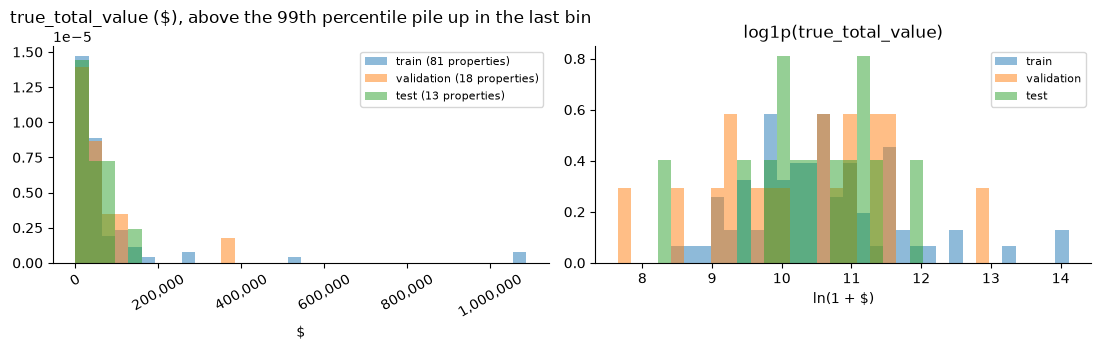

Kolmogorov-Smirnov, train vs validation (property level, 18 homes): statistic = 0.167, p-value = 0.755 -> no clear difference
Kolmogorov-Smirnov, train vs test (property level, 13 homes): statistic = 0.141, p-value = 0.954 -> no clear difference


In [11]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from scipy.stats import ks_2samp
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False})

print("train_df (first rows):")
display(train_df.head())
print("val_df (first rows):")
display(val_df.head())
print("test_df (first rows):")
display(test_df.head())

p_train = train_df.groupby("Property_ID")["true_total_value"].first()
p_val = val_df.groupby("Property_ID")["true_total_value"].first()
p_test = test_df.groupby("Property_ID")["true_total_value"].first()

def describe(s):
    return pd.Series({"properties": len(s), "mean": s.mean(), "median": s.median(), "std": s.std(), "min": s.min(), "max": s.max(), "skewness": s.skew()})

print("true_total_value ($), one value per property:")
display(pd.DataFrame({"train": describe(p_train), "validation": describe(p_val), "test": describe(p_test)}).round(2))
print("log1p(true_total_value):")
display(pd.DataFrame({"train": describe(np.log1p(p_train)), "validation": describe(np.log1p(p_val)), "test": describe(np.log1p(p_test))}).round(2))

allv = np.concatenate([p_train, p_val, p_test])
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
cap = np.percentile(allv, 99)
bins = np.linspace(0, cap, 35)
for s, lab in [(p_train, "train"), (p_val, "validation"), (p_test, "test")]:
    axes[0].hist(s.clip(upper=cap), bins=bins, alpha=.5, density=True, label=f"{lab} ({len(s)} properties)")
axes[0].set_title("true_total_value ($), above the 99th percentile pile up in the last bin")
axes[0].set_xlabel("$")
axes[0].legend(fontsize=8)
axes[0].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:,.0f}"))      # plain dollars (10,000 / 20,000 ...), no 1e6 offset
axes[0].tick_params(axis="x", labelrotation=30)
lb = np.linspace(np.log1p(allv.min()), np.log1p(allv.max()), 35)
for s, lab in [(p_train, "train"), (p_val, "validation"), (p_test, "test")]:
    axes[1].hist(np.log1p(s), bins=lb, alpha=.5, density=True, label=lab)
axes[1].set_title("log1p(true_total_value)")
axes[1].set_xlabel("ln(1 + $)")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

for name, other in [("validation", p_val), ("test", p_test)]:
    ks = ks_2samp(p_train, other)
    print(f"Kolmogorov-Smirnov, train vs {name} (property level, {len(other)} homes): statistic = {ks.statistic:.3f}, p-value = {ks.pvalue:.3f} -> "
          + ("no clear difference" if ks.pvalue > 0.05 else "the distributions differ"))

## Saved data

`train_df`, `val_df`, `test_df`, `unlisted_df` and the property mapping were written in Block 6. This cell lists what is in `data/interim/regression/` and `data/processed/regression/` and re-reads the modelling tables to confirm they match what is in memory.

In [12]:
same = {n: pd.read_parquet(PROCESSED / f"{n}.parquet").equals(d) for n, d in [("train_df", train_df), ("val_df", val_df), ("test_df", test_df)]}
print("re-read parquet equals the table in memory:", same)
files = [{"folder": str(p.parent.relative_to("../..")).replace("\\", "/"), "file": f.name, "KB": round(f.stat().st_size / 1024, 1)}
         for p in (INTERIM, PROCESSED) for f in sorted(p.iterdir()) if f.is_file()]
pd.DataFrame(files).set_index(["folder", "file"])

re-read parquet equals the table in memory: {'train_df': True, 'val_df': True, 'test_df': True}


KB
folder         file                            
data/interim   assets.parquet             774.1
               customer_profiles.parquet   16.2
               customers.parquet           26.4
               properties.parquet          47.3
               property_split.csv           6.2
data/processed test_df.parquet             24.6
               train_df.parquet            65.4
               unlisted_df.parquet         37.0
               val_df.parquet              27.9

## Final check: does the property split match the classification model?

The split used here is compared with the classification model's own split, which is rebuilt from `model_state.csv` in Block 6 with the code of its `03_fm_modelling`. Three conditions are checked:
- The rebuilt split must reproduce the printed counts of the classification notebook and place every property in exactly one set.
- Every regression train, validation and test property must have the same label in the classification model.
- No regression train or validation property may be a classification test property, because that would be leakage.

In [13]:
# 1. the rebuilt split reproduces the classification notebook's printed counts, and no property sits in two sets
counts = {s: (int((state_split == s).sum()), int(state_pid[state_split == s].nunique())) for s in ["train", "validation", "test"]}
print("states / properties:", counts, " <- 03_fm_modelling: train 309/163, validation 67/35, test 55/36")
print("matches the classification notebook:", counts == {"train": (309, 163), "validation": (67, 35), "test": (55, 36)})
print("properties with more than one split label:", int((pd.DataFrame({"p": state_pid, "s": state_split}).groupby("p")["s"].nunique() > 1).sum()), " <- must be 0")

# 2. the regression sets follow it, property by property (only homes that have a label are in train / validation / test)
mine = pd.concat([pd.Series("train", index=list(ids["train"])), pd.Series("validation", index=list(ids["validation"])),
                  pd.Series("test", index=list(ids["test"]))])
j = pd.DataFrame({"regression": mine})
j["classification"] = prop_cls.reindex(j.index).fillna("not_in_classification")
print()
print("regression properties in train / validation / test:", len(j), "| of them in the classification data:", int((j["classification"] != "not_in_classification").sum()),
      "| not in it (unlisted, kept out or in train):", int((j["classification"] == "not_in_classification").sum()))
labelled = j[j["classification"] != "not_in_classification"]
print("properties where the regression split differs from the classification split:", int((labelled["regression"] != labelled["classification"]).sum()), " <- must be 0")
for s in ["train", "validation", "test"]:
    their = set(prop_cls.index[prop_cls == s])
    mine_s = set(j.index[j["regression"] == s])
    bad = [p for p in mine_s if p in prop_cls.index and prop_cls[p] != s]
    print(f"  {s:<10}: classification {len(their):>3} properties | with a regression basket {len(their & set(j.index)):>3} | in regression {s} {len(mine_s):>3} "
          f"| regression {s} properties with a different classification label: {len(bad)}  <- must be 0")

# 3. every classification state of a regression test property is a classification TEST state
test_pids = list(ids["test"])
print()
print("classification states of regression test properties:", int(state_pid.isin(test_pids).sum()),
      "| of them labelled test:", int(((state_pid.isin(test_pids)) & (state_split == "test")).sum()))
print("regression train / validation properties that are classification TEST properties (leakage):",
      int(((j["regression"] != "test") & (j["classification"] == "test")).sum()), " <- must be 0")
pd.crosstab(j["regression"], j["classification"])

states / properties: {'train': (309, 163), 'validation': (67, 35), 'test': (55, 36)}  <- 03_fm_modelling: train 309/163, validation 67/35, test 55/36
matches the classification notebook: True
properties with more than one split label: 0  <- must be 0

regression properties in train / validation / test: 112 | of them in the classification data: 112 | not in it (unlisted, kept out or in train): 0
properties where the regression split differs from the classification split: 0  <- must be 0
  train     : classification 163 properties | with a regression basket  81 | in regression train  81 | regression train properties with a different classification label: 0  <- must be 0
  validation: classification  35 properties | with a regression basket  18 | in regression validation  18 | regression validation properties with a different classification label: 0  <- must be 0
  test      : classification  36 properties | with a regression basket  13 | in regression test  13 | regression test propertie

classification,test,train,validation
regression,,,
test,13,0,0
train,0,81,0
validation,0,0,18


**Next:** `03_ky_modelling_xgboost_lightgbm` trains and tunes XGBoost and LightGBM on `train_df` and chooses their number of trees on `val_df`. After that, `04_ky_ensemble_and_intervals` builds the blend and the 70% interval on the validation set.

## What the data preparation produced (numbers from the run above)

- **Data:** The notebook produces **1,840 rows** from **159 properties**. Only 159 of the 795 properties (20%) own 10 or more valued non-vehicle items, so the other 636 are skipped.
- **Fewer homes at large N:** 159 properties can give N = 10, 101 can give N = 20, 68 can give N = 30, and only **40 can give N = 50**.
- **Split:** The train, validation and test sets follow the classification model's grouped split by `Property_ID`. Of the 159 properties, 112 have a label there, which gives **train 81 properties with 1,030 rows, validation 18 with 230 rows and test 13 with 150 rows**. The other **47 properties (430 rows) are not in the classification data**, because they are homes with 10 or more items that never form a classification state. They have no label to follow, so they are kept out and saved as `unlisted_df.parquet`. Setting `INCLUDE_UNLISTED_IN_TRAIN = True` adds them to train instead.
- **Only part of the classification sets can be used:** 81 of the 163 classification train properties, 18 of the 35 validation properties and **13 of the 36 test properties** own 10 or more items. The remaining properties have fewer items and therefore no basket.
- **Validation and test are small:** The properties by N (train / validation / test) are 81 / 18 / 13 at N = 10, 57 / 13 / 9 at N = 20, 42 / 9 / 5 at N = 30 and 26 / 6 / **3** at N = 50. Any validation or test result, especially at N = 30 and 50, therefore rests on a handful of homes.
- **Target distribution:** In train the mean is $85,081, the median $35,656 and the maximum $1,349,866. In validation the mean is $59,273, the median $40,205 and the maximum $360,420. In test the mean is $47,796, the median $32,169 and the maximum $138,593. The Kolmogorov-Smirnov test gives p = 0.755 for train against validation and p = 0.954 for train against test, so there is no clear difference, although with 18 and 13 homes the test has little power. The $1.35M home is in train.
- **Match with the classification model:** The split rebuilt from `model_state.csv` reproduces the counts of `03_fm_modelling` (train 309 rows from 163 properties, validation 67 from 35, test 55 from 36). Every regression train, validation and test property has the same label in the classification model (0 differences). No train or validation property is a classification test property (0), and all 28 classification states of the regression test properties are labelled test.
- **Whole-home baskets:** 90 rows (4.9% of all rows, from 18 properties) come from homes that own exactly N items. In these rows the basket is the whole home and `sum_value == true_total_value`, so they are trivially predictable (55 of them at N = 10). They are kept in the data and should be kept in mind when reading results.
- **Basket coverage grows with N:** The median basket covers 38% of the home's items at N = 10, 48% at N = 20, 57% at N = 30 and 71% at N = 50. Errors at different N are therefore measured on **different and larger homes** and are not directly comparable.
- **Customers:** 3 customers own properties in more than one of train, validation and test, because the split is made by property as in the classification model.
- **Data preparation:** 22 vehicle items are excluded, 215 items without a value are dropped, 790 of the 795 properties have a target, there are 26 feature columns, and no property appears in more than one set.
- **Files:** `data/processed/regression/` holds `train_df.parquet`, `val_df.parquet`, `test_df.parquet` and `unlisted_df.parquet`. `data/interim/regression/` holds the four sheet copies (`assets`, `properties`, `customers` and `customer_profiles`) and `property_split.csv`.